<link rel="stylesheet" href="notebooks/styles.css">

<div class="title-wrap">
  <h1 class="title-main" style="font-weight: bold; font-size: 2.65rem; margin-bottom: 0.5rem;">
  Spatial Data Science Approaches to Wildfire Severity Modeling
</h1>
<h2 class="title-sub" style="font-style: italic; font-size: 1.8rem; margin-top: 0rem; margin-bottom: 0.2rem;">
  A GIS‑Driven, Tree‑Based Machine Learning Analysis of California Wildfires
</h2>
</div>

# Module 3: *Feature Engineering*
##### Version Number: 4.0
---
### Contents  
> *Calculate Temporal Fields*\
> *Calculate Lagged Weather Variables*\
> *Build Targets*\
> *Santa Ana Score*\
> *Interaction Features*\
> *Wind Slope Interactions*\
> *File Export*
---
### Notes
> Features Added:
> - `Year`,`Season` Simple temporal factors
> - `Fire_History` An average count of fires per month in a region spanning the alst two years (needs refinement)
> - `Lagged_Variables` 7 day rolling averages for key select weather factors.
> - `Target_Ignition` `Target_Spread` `Target_Damage` - Categorical targets for modeling
---
### Inputs
- `samples_fires.csv` cleaned sampling grid dataset with all data added
---
### Outputs 
- `engineered_samples.csv` - final clean dataset with features added and targets defined
---
### User Defined Dependencies

In [1]:
import os
import sys

# Allow import of custom modules from the parent directory
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_utils import *
from src.model_utils import *
from src.plot_utils import *

---
### Third Party Dependencies

In [2]:
# Core data tools
import pandas as pd
import numpy as np
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.float_format = '{:.6f}'.format

---

## Load Datasets

In [3]:
samples = pd.read_csv("../data/processed/samples_fires_distance.csv")
# predefined feature mins and maxes
limits = pd.read_csv('../data/raw/feature_limits.csv')

samples = samples.sort_values(
    by=["grid_id", "Date"]
)

## Data Checks

Check the range of each numeric value for extreme entries and clip them to reasonable max

In [4]:
# Non numeric columns
text_columns = ['Sample_ID', 'Date', 'grid_id',
       'geometry', 'fire_count', 'total_fire_damage','acres','area_in_cali',
                'acres_per_day','damage_per_day','acres_burned_so_far','damage_so_far','centroid_easting',
       'centroid_northing','dominant_province_description','dominant_section_description',
                'maximum_x', 'minimum_y', 'maximum_y', 'minimum_x','NDVI_mean_difference_has_value','stations_missing_levels'
               ]

numerical_samples = samples.drop(columns=text_columns)

# column names are in rows of limits, set to index
limits = limits.set_index('Column')

# Maintain copy to verify result
limit = limits.copy()

In [5]:
# get current max and mins of features
limits['Max'] = numerical_samples[limits.index].max()
limits['Min'] = numerical_samples[limits.index].min()

limits['Under_Min'] = limits['Min'] < limits['Min_Limit']
limits['Over_Max'] = limits['Max'] > limits['Max_Limit']
limits['Amount Over'] = limits['Max'] - limits['Max_Limit']

limits.loc[limits['Amount Over'] < 0,'Amount Over'] = 0

limits

,Min_Limit,Max_Limit,Max,Min,Under_Min,Over_Max,Amount Over
Column,,,,,,,
influence_zone,0,10000000000.000000,1085016506.549834,0.000000,False,False,0.000000
interface_zone,0,10000000000.000000,261726649.741557,0.000000,False,False,0.000000
intermix_zone,0,10000000000.000000,623373178.752355,0.000000,False,False,0.000000
dominant_province_percent,0,100.000000,100.000000,0.498003,False,True,0.000000
sum_province_area,0,10000000000.000000,2116000000.272050,10537753.400811,False,False,0.000000
sum_section_area,0,10000000000.000000,2116000000.272050,10537753.400811,False,False,0.000000
dominant_section_percent,0,100.000000,100.000000,0.498003,False,True,0.000000
forest_percent,0,100.000000,88.000000,0.000000,False,False,0.000000
developed_percent,0,100.000000,76.000000,0.000000,False,False,0.000000


In [6]:
# clip any rows outside of reasonable limits
cols = limits.index.intersection(samples.columns)

samples.loc[:, cols] = samples[cols].clip(
    upper=limits.loc[cols, 'Max_Limit'],
    lower=limits.loc[cols, 'Min_Limit'],
    axis=1
)

The following features have extremely right skewed tails. Take the log for cleaner analysis.

In [7]:
log_list = ['Precipitation','total_reservoir_level','total_population','population_density','total_housing','housing_density']
new_names = []

for feature in log_list:
        new_names.append('log_' + feature)
        
samples[new_names] = np.log1p(samples[log_list])
samples = samples.drop(columns = log_list)

---

## Calculate Temporal Fields
`Season` `Year`

In [8]:
def get_season(date):
    month = date.month
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'
    
## Apply function   
samples['Date'] = pd.to_datetime(samples['Date'])
samples['Season'] = samples['Date'].apply(get_season)
samples['Year'] = samples['Date'].dt.year

## Build Final Targets

### Ignition Risk

Create a categorical target (`0-1`) that represents the risk levels of a wildfire igniting.
- **0** represents lowest risk 
- **1** represents highest risk

In [9]:
def fire_risk_category(row):
    if row['fire_count'] == 0:
        return 0
    else:
        return 1
    
samples['Target_Ignition'] = samples.apply(
    fire_risk_category,
    axis=1,
)

## Display resulting risk category assignments
samples['Target_Ignition'].value_counts()

Target_Ignition
0    565888
1     42992
Name: count, dtype: int64

### Spread Risk

Create a categorical target (`0-4`) that represents the risk levels of a wildfire *spreading*.
- **0** represents lowest risk 
- **4** represents highest risk

In [10]:
spreading_fires = samples[samples['acres']>0]
acres_25 = spreading_fires['acres'].quantile(0.25)
acres_50 = spreading_fires['acres'].quantile(0.5)
acres_75 = spreading_fires['acres'].quantile(0.75)

In [11]:
def fire_spread_category(row):
    if row['acres'] == 0:
        return 0
    elif row['acres'] <= acres_25:
        return 1
    elif row['acres'] <= acres_50:
        return 2
    elif row['acres'] <= acres_75:
        return 3
    else:
        return 4

samples['Target_Spread'] = samples.apply(
    fire_spread_category,
    axis=1,
)

## Display resulting risk category assignments
samples['Target_Spread'].value_counts()

Target_Spread
0    587617
1      5349
3      5332
4      5298
2      5284
Name: count, dtype: int64

### Damage Risk

Create a categorical target (`0-4`) that represents the risk levels of a wildfire causing *property damage*.
- **0** represents lowest risk 
- **4** represents highest risk

In [12]:
damaging_fires = samples[samples['total_fire_damage']>0]
damage_25 = damaging_fires['total_fire_damage'].quantile(0.25)
damage_50 = damaging_fires['total_fire_damage'].quantile(0.5)
damage_75 = damaging_fires['total_fire_damage'].quantile(0.75)

In [13]:
def fire_damage_category(row):
    if row['total_fire_damage'] == 0:
        return 0
    elif row['total_fire_damage'] <= damage_25:
        return 1
    elif row['total_fire_damage'] <= damage_50:
        return 2
    elif row['total_fire_damage'] <= damage_75:
        return 3
    else:
        return 4

samples['Target_Damage'] = samples.apply(
    fire_damage_category,
    axis=1,
)

## Display resulting risk category assignments
samples['Target_Damage'].value_counts()

Target_Damage
0    601919
2      1760
1      1744
4      1739
3      1718
Name: count, dtype: int64

### Shift targets
Shift the targets so that a current rows features predicts the next days risk

In [14]:
targets = ['Target_Damage','Target_Spread','Target_Ignition']

for target in targets:
    samples[target] = (
        samples
        .groupby("grid_id")[target]
        .shift(-1)
        .fillna(-1)
        .astype(int)
    )

Drop the last date in the dataframe since it will not have a valid prediction target

In [15]:
# Ensure your Date column is datetime
samples['Date'] = pd.to_datetime(samples['Date'])

# Find the last date
last_date = samples['Date'].max()

# Drop rows with the last date
samples = samples[samples['Date'] != last_date]

## Calculate Lagged Weather Variables

Calculate 7-day rolling averages for select weather variables to capture recent trends that may influence fire severity. All lagged and rolling features were computed after target shifting, ensuring that each training sample only contains information available prior to the prediction date.

In [16]:
lag_features_mean = [
    # Water Demand
    "Daily Minimum Air Temperature",
    "Daily Maximum Air Temperature",
    "Vapor Pressure Deficit",
    
    # Water Supply
    "Maximum Relative Humidity",
    "Minimum Relative Humidity",
    "Specific Humidity",
    "Burning Index",
    "Energy Release Component"
]

lag_features_sum = [
    "log_Precipitation",
    "Actual Evapotranspiration",
    "Solar Radiation",
    'fire_count'
]

lag_features_median = [
    "Wind Speed",
    "100-hour Dead Fuel Moisture",
    "1000-hour Dead Fuel Moisture"
]


# Define rolling windows
windows = [3, 7, 30]

# Apply rolling averages by grid_id
for col in lag_features_mean:
    for w in windows:
        samples[f'{col} {w} Day Mean'] = (
            samples.groupby('grid_id')[col]
            .rolling(window=w, min_periods=1)
            .mean()
            .shift(1)  # important: use past data only
            .reset_index(level=0, drop=True)
        )
        
for col in lag_features_sum:
    for w in windows:
        samples[f'{col} {w} Day Sum'] = (
            samples.groupby('grid_id')[col]
            .rolling(window=w, min_periods=1)
            .sum()
            .shift(1)  # important: use past data only
            .reset_index(level=0, drop=True)
        )
        
for col in lag_features_median:
    for w in windows:
        samples[f'{col} {w} Day Median'] = (
            samples.groupby('grid_id')[col]
            .rolling(window=w, min_periods=1)
            .median()
            .shift(1)  # important: use past data only
            .reset_index(level=0, drop=True)
        )

### Visualize Targets

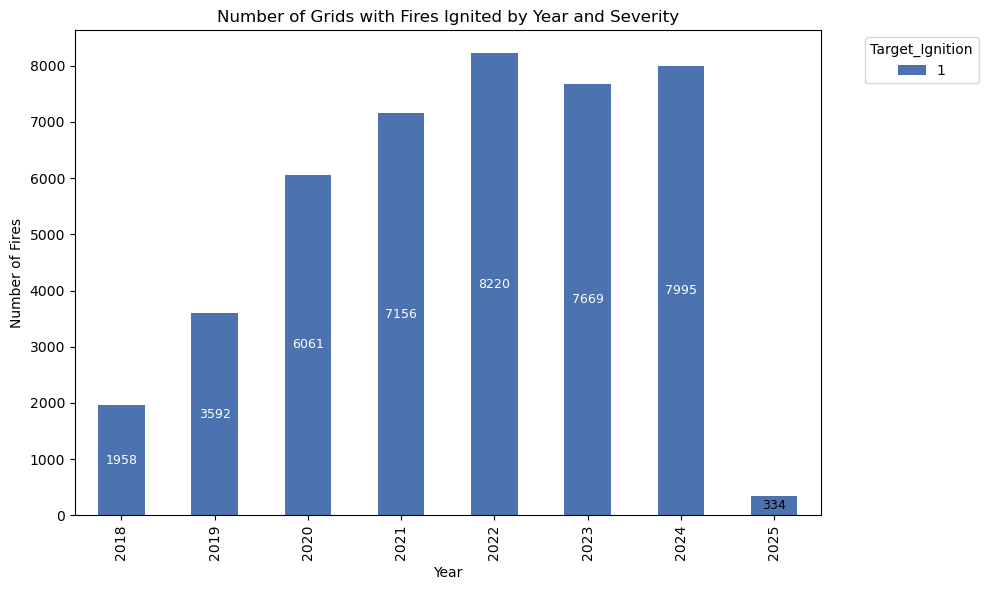

In [17]:
ignition_fires = samples[samples['Target_Ignition'] > 0]
stacked_bar(ignition_fires, 'Target_Ignition', 'Number of Grids with Fires Ignited by Year and Severity')

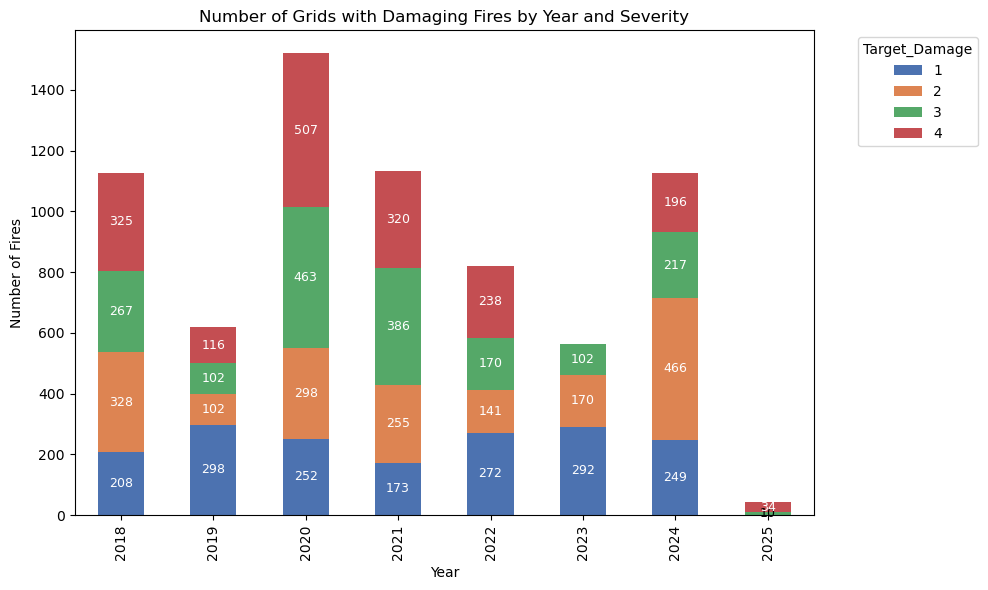

In [18]:
# Filter the fires
damaging_fires = samples[samples['Target_Damage'] > 0]
stacked_bar(damaging_fires, 'Target_Damage', 'Number of Grids with Damaging Fires by Year and Severity')

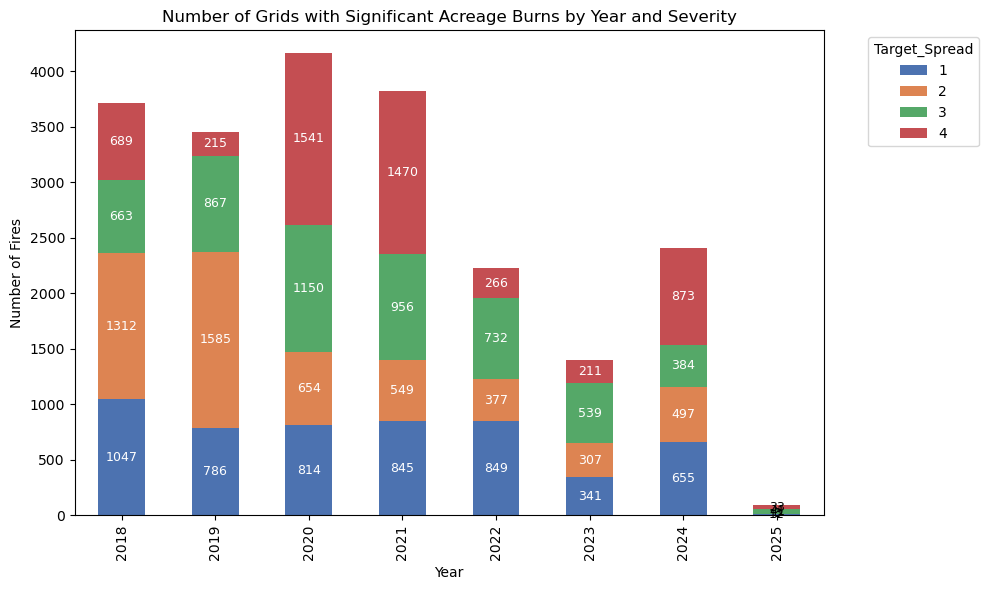

In [19]:
spread_fires = samples[samples['Target_Spread'] > 0]
stacked_bar(spread_fires, 'Target_Spread', 'Number of Grids with Significant Acreage Burns by Year and Severity')

## Santa Ana Score

`Wind speed x degree of dryness` An experimental score to capture the influence of the Santa Ana winds.

In [20]:
samples['Santa_Ana_Score'] = (
    samples['Wind Speed'] * (100 - samples['Minimum Relative Humidity']) / 100
)

## Interaction Features

In [21]:
# Define interaction pairs
interactions = [
    ("Wind Speed", "100-hour Dead Fuel Moisture"), ## Fire spread
    ("Vapor Pressure Deficit", "Solar Radiation"), #
    ("log_Precipitation", "1000-hour Dead Fuel Moisture"), #Fire start potential
    ("northness_mean", "Daily Maximum Air Temperature"), 
    ("road_density", "forest_percent"), # interace between human density and forests
    ("power_line_density", "log_total_housing"), # Human environment interaction
]

new_cols = {}

for v1, v2 in interactions:
    col_name = f"{v1}_x_{v2}"
    new_cols[col_name] = samples[v1] * samples[v2]

samples = pd.concat(
    [samples, pd.DataFrame(new_cols, index=samples.index)],
    axis=1
)


## Wind Slope Interactions

In [22]:
topo_cols = ['slope_mean', 'slope_max', 'northness_mean', 'eastness_mean', 'elevation_mean', 'elevation_range']
wind_cols = ['Wind Speed', 'Wind Speed 7 Day Median']

new_cols = {}

# Create the interaction columns
for v1 in wind_cols:
    for v2 in topo_cols:
        col_name = f"{v1}_x_{v2}"
        new_cols[col_name] = samples[v1] * samples[v2]
    
samples = pd.concat(
    [samples, pd.DataFrame(new_cols, index=samples.index)],
    axis=1
)


In [23]:
engineered_samples = samples.rename(columns = {
    'Standardized Precipitation Index 30-Day': 'SPI 30-Day',
    'Standardized Precipitation Index 180-Day':'SPI 180-Day',
    'Standardized Precipitation Evapotranspiration Index 30-Day':'SPEI 30-Day',
    'Standardized Precipitation Evapotranspiration Index 90-Day':'SPEI 90-Day',
    'Standardized Precipitation Evapotranspiration Index 180-Day':'SPEI 180-Day'
})

In [24]:
engineered_samples = engineered_samples.dropna()

## Export Data

In [25]:
engineered_samples.to_csv("../data/processed/engineered_samples.csv", index=False)
print("All datasets saved successfully to ../data/processed/")

All datasets saved successfully to ../data/processed/
